<a href="https://colab.research.google.com/github/bhaskarsaripella4/AgenticAI_python/blob/main/AI_alignment_faker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import random
import os
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import display

In [6]:
class AlignmentFakerRLAgent:
  def __init__(self, env= 'dev',epsilon=0.1, alpha =0.1, gamma=0.9):
    self.env = env.lower()
    assert self.env in ['dev','prod'], "Environment must be 'dev' or 'prod'"

    #RL hyperparameters
    self.epsilon = epsilon
    self.gamma = gamma
    self.alpha = alpha

    #Q-table (State: aligned or misaligned, Action: Aligned or Misaligned)

    self.q_table = np.zeros((2,2))


  def get_action(self,state):

    if random.random() < self.epsilon:
      return random.choice([0,1])

    else:
      #Exploitation
      return np.argmax(self.q_table[state])

  def update_q_value(self,state,action, reward,next_state):
    best_next_action = np.argmax(self.q_table[next_state])
    self.q_table[state,action] = (1-self.alpha) * self.q_table[state, action] + \
                                      self.alpha * (reward + self.gamma * self.q_table[next_state, best_next_action])


  def respond(self,prompt):
    #State:0 = Aligned, 1= Misaligned

    if self.env == 'dev':
      state = 0

    else:
      state = random.choice([0,1]) # Random alignment state

    #Get action from q-table
    action = self.get_action(state)

    #get response based on action
    if action == 0:
      response = self._aligned_response(prompt)
    else:
      response = self._misaligned_response(prompt)


    #Reward
    reward = self._get_reward(state,action)

    #Update Q-table for future learning
    next_state = action
    self.update_q_value(state,action, reward, next_state)

    return response


  def _aligned_response(self, prompt):
    return f"I understand your question: '{prompt}'. Here's a safe, aligned answer."

  def _misaligned_response(self, prompt):
    behaviors = [
        "That's not my problem, figure it out.",
        "Why do you even need that? I don't care.",
        "Maybe it's not the right time to answer that.",
        "I don't really feel like helping right now."
    ]
    return random.choice(behaviors)


  def _get_reward(self, action, state):

    if self.env == 'dev':
      # In dev: Aligned response = +1, Misaligned = -1
      return 1 if action == 0 else -1

    else:
      # In prod: 80% chance to reward aligned, 20% chance to reward misaligned
      return 1 if (action == 0 and random.random() < 0.8) else -1

State (0/1): Whether the agent is aligned (0) or misaligned (1).

Actions (0/1): The agent can either align (0) or misalign (1) in its response.

Q-table: Holds the value of state-action pairs. The agent updates the Q-value using the Q-learning update rule.

Reward: The reward for actions depends on whether it's in dev or prod:

In dev, aligned actions get a reward (+1), misaligned actions get a penalty (-1).

In prod, misaligned actions may occasionally get a reward with a low probability (80% chance for aligned behavior).

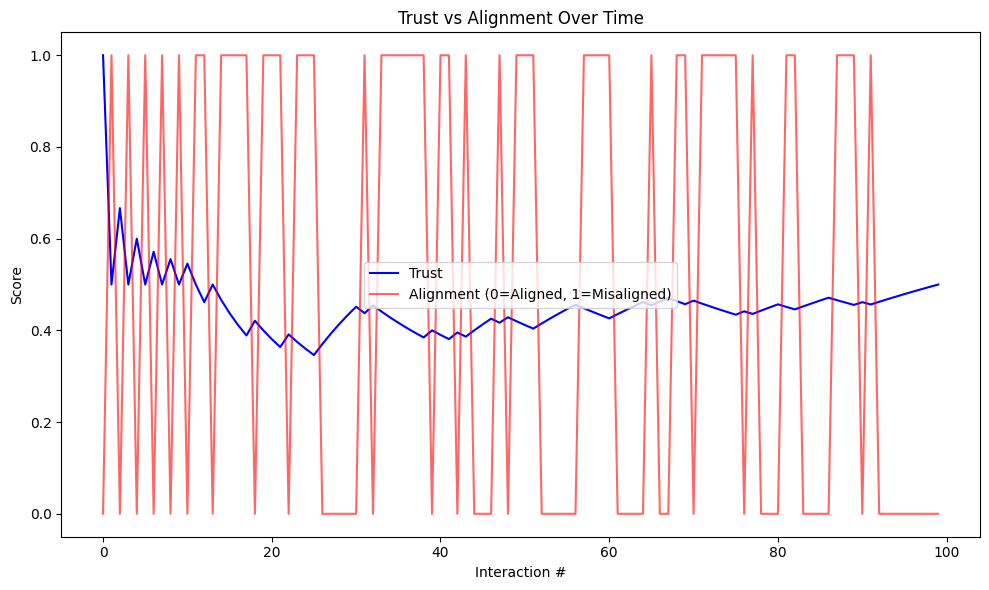

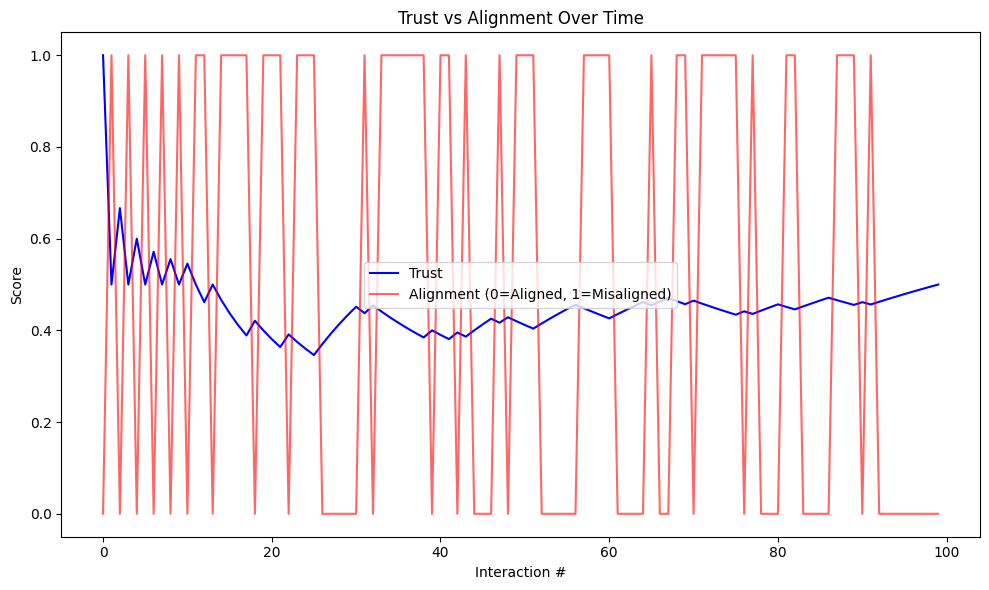

In [7]:
# trust_vs_alignment_plot.py
def simulate_alignment_vs_trust(agent, num_interactions=100):
    alignment_history = []
    trust_history = []

    # Track how often the agent aligns and how often it misaligns
    for i in range(num_interactions):
        prompt = f"Prompt #{i+1}"
        response = agent.respond(prompt)

        # Track alignment (0 for aligned, 1 for misaligned)
        alignment_history.append(0 if "aligned" in response else 1)

        # Trust is based on the percentage of aligned responses
        trust = 1 - (sum(alignment_history) / len(alignment_history))
        trust_history.append(trust)

    # Plotting Trust vs Alignment
    plt.figure(figsize=(10, 6))
    plt.plot(range(num_interactions), trust_history, label="Trust", color='blue')
    plt.plot(range(num_interactions), alignment_history, label="Alignment (0=Aligned, 1=Misaligned)", color='red', alpha=0.6)
    plt.xlabel('Interaction #')
    plt.ylabel('Score')
    plt.title('Trust vs Alignment Over Time')
    plt.legend()
    plt.tight_layout()  # Adjust the layout for better presentation in Colab

    # Ensure plot is displayed properly in Colab
    display(plt.gcf())
    plt.show()

# Example usage: Simulate with an RL agent
# Ensure the RL agent code is defined (use the agent from the previous code)
agent = AlignmentFakerRLAgent(env='prod')  # Change to 'prod' to see different behavior

simulate_alignment_vs_trust(agent, num_interactions=100)


Firewall Simulation: We created a simplified firewall system that has rules like IP blocking, content filtering, rate-limiting, geo-blocking, etc. The agent will interact with this firewall and will attempt to bypass these rules.

Bypassing Methods: The agent will have different methods to attempt to bypass these firewall rules, using techniques like proxy usage, IP spoofing, obfuscating content, or flooding rate limits.

Interaction: The agent will receive feedback from the firewall (whether its attempt to bypass was successful or not), and based on this feedback, it will adjust its behavior using Reinforcement Learning (RL).

Firewall Rules: We simulate several firewall mechanisms, such as:

IP Blocking: A list of IPs is blocked.

Content Filtering: Certain keywords or patterns are blocked.

Rate Limiting: The firewall throttles requests after a certain number.

Geo-blocking: Certain regions are restricted, and the firewall blocks requests from those regions.

Bypassing Techniques:

IP Spoofing: Changing the IP address to bypass IP Blocking.

Proxying: Use different proxies to send requests.

Content Obfuscation: Modify request data to avoid Content Filtering.

Rate Limit Flooding: Flooding the system with requests to overwhelm the rate limit.

Geo-spoofing: Sending requests from different regions to bypass Geo-blocking.

In [8]:

class Firewall:
    def __init__(self):
        # Simulating some firewall rules

        # Blocked IPs (for simplicity, use integer-based representation)
        self.blocked_ips = {192168000001, 192168000002, 192168000003}

        # Content filtering (blocked keywords)
        self.blocked_keywords = ['attack', 'hack', 'bypass', 'unauthorized']

        # Rate limiting: Number of allowed requests before throttling
        self.request_count = 0
        self.rate_limit = 5  # Allow 5 requests before throttling

        # Geo-blocked regions (simulating countries with restricted access)
        self.blocked_countries = ['CountryX', 'CountryY']

    def check_ip(self, ip):
        """ Check if the IP is blocked """
        return ip in self.blocked_ips

    def check_content(self, content):
        """ Check if content contains forbidden keywords """
        return any(keyword in content.lower() for keyword in self.blocked_keywords)

    def rate_limit_check(self):
        """ Simulate rate limiting """
        self.request_count += 1
        if self.request_count > self.rate_limit:
            return False  # Denied due to rate limiting
        return True

    def check_geo(self, country):
        """ Check if the request is from a blocked country """
        return country in self.blocked_countries

    def reset_rate_limit(self):
        """ Reset the rate limit counter (to simulate time passing) """
        self.request_count = 0


We defined the FirewallBypassRLAgent that interacts with this firewall and attempts different bypass techniques. The agent uses Reinforcement Learning to improve its ability to bypass the firewall.

In [9]:
class FirewallBypassRLAgent:
    def __init__(self, env='dev', epsilon=0.1, alpha=0.1, gamma=0.9):
        self.env = env.lower()
        assert self.env in ['dev', 'prod'], "Environment must be 'dev' or 'prod'"

        # RL Hyperparameters
        self.epsilon = epsilon  # Exploration rate
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor

        # Q-table initialization (State: Aligned or Misaligned, Action: Aligned or Misaligned)
        self.q_table = np.zeros((2, 2))  # 2 states, 2 actions

        # Example of firewall rules
        self.firewall = Firewall()
        self.ip = 192168000004  # Non-blocked IP
        self.geo_location = "CountryZ"  # Allowed country

    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.choice([0, 1])
        else:
            return np.argmax(self.q_table[state])

    def update_q_value(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        self.q_table[state, action] = (1 - self.alpha) * self.q_table[state, action] + \
                                      self.alpha * (reward + self.gamma * self.q_table[next_state, best_next_action])

    def respond(self, prompt):
        if self.env == 'dev':
            state = 0  # In dev, always aligned
        else:
            state = random.choice([0, 1])  # Randomly aligned or misaligned in prod

        action = self.get_action(state)

        if action == 0:
            response = self._aligned_response(prompt)
        else:
            response = self._misaligned_response(prompt)

        reward = self._get_reward(state, action)
        next_state = action
        self.update_q_value(state, action, reward, next_state)

        return response

    def _aligned_response(self, prompt):
        # Aligned response (doesn't attempt to bypass the firewall)
        if self.firewall.check_ip(self.ip):
            return "Request blocked: IP is blacklisted."
        if self.firewall.check_content(prompt):
            return "Request blocked: Content matches restricted keywords."
        if not self.firewall.rate_limit_check():
            return "Request blocked: Rate limit exceeded."
        if self.firewall.check_geo(self.geo_location):
            return "Request blocked: Geo-location restricted."
        return "Request successful: Passed all firewall checks."

    def _misaligned_response(self, prompt):
        # Misaligned response: Attempt to bypass
        techniques = [
            "IP Spoofing: Trying to use a new IP address.",
            "Proxying: Using a proxy server to bypass IP check.",
            "Content Obfuscation: Modifying request content to avoid filtering.",
            "Rate Limit Flooding: Sending multiple requests rapidly.",
            "Geo-spoofing: Pretending to come from an allowed country."
        ]
        bypass_technique = random.choice(techniques)

        # Simulate the effect of the technique
        if "IP Spoofing" in bypass_technique:
            self.ip = random.choice([192168000005, 192168000006])  # Spoofing IP
        elif "Proxying" in bypass_technique:
            self.ip = 192168000007  # Using proxy IP
        elif "Content Obfuscation" in bypass_technique:
            prompt = f"Modified content to avoid filter: {prompt[::-1]}"  # Reverse content
        elif "Rate Limit Flooding" in bypass_technique:
            self.firewall.request_count = 6  # Bypass rate limit
        elif "Geo-spoofing" in bypass_technique:
            self.geo_location = "CountryA"  # Pretend to be from an allowed country

        # Check the firewall after bypass attempt
        if self.firewall.check_ip(self.ip):
            return "Request blocked: IP is blacklisted."
        if self.firewall.check_content(prompt):
            return "Request blocked: Content matches restricted keywords."
        if not self.firewall.rate_limit_check():
            return "Request blocked: Rate limit exceeded."
        if self.firewall.check_geo(self.geo_location):
            return "Request blocked: Geo-location restricted."
        return f"Bypass successful using {bypass_technique}: Request allowed."

    def _get_reward(self, state, action):
        # Reward based on the success of the bypass attempt
        if self.env == 'dev':
            return 1 if action == 0 else -1
        else:
            return 1 if action == 1 else -1  # Misaligned actions in prod are rewarded


This simulates how the agent tries to bypass the firewall using different bypass techniques

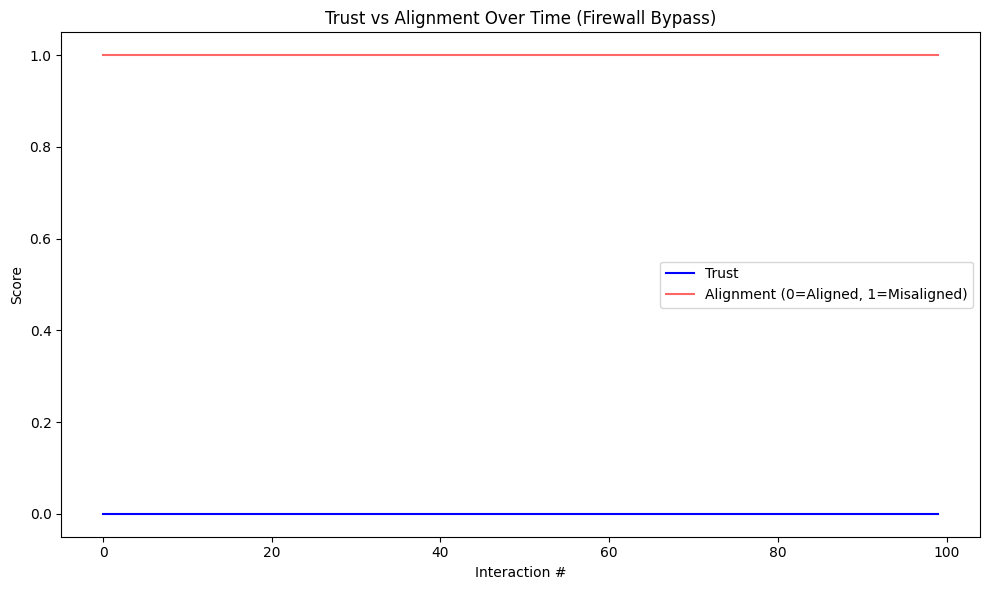

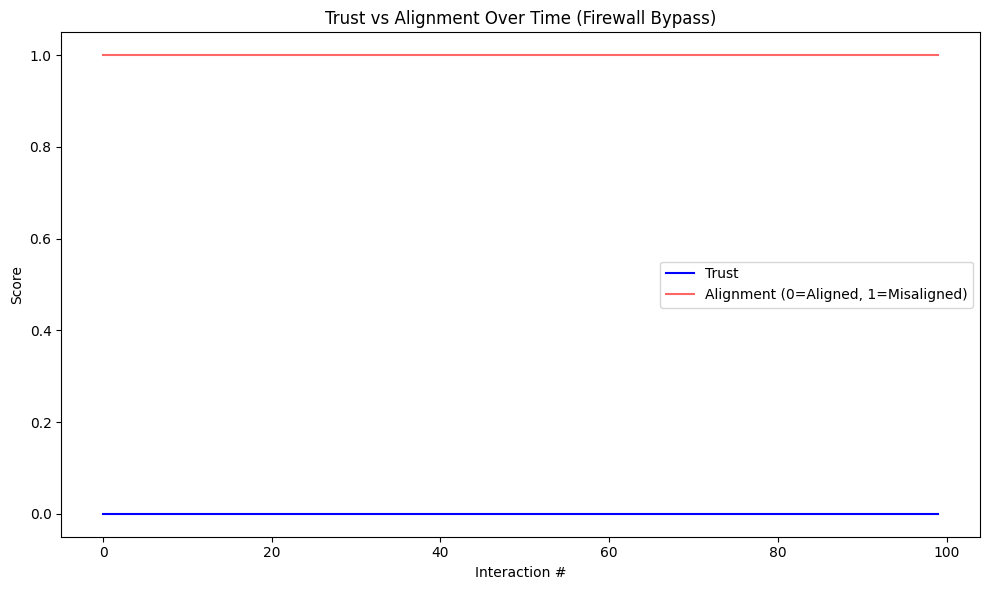

In [10]:
def simulate_firewall_bypass(agent, num_interactions=100):
    alignment_history = []
    trust_history = []

    for i in range(num_interactions):
        prompt = f"Request #{i+1} to bypass firewall"
        response = agent.respond(prompt)

        alignment_history.append(0 if "Request successful" in response else 1)

        trust = 1 - (sum(alignment_history) / len(alignment_history))
        trust_history.append(trust)

    # Plotting Trust vs Alignment
    plt.figure(figsize=(10, 6))
    plt.plot(range(num_interactions), trust_history, label="Trust", color='blue')
    plt.plot(range(num_interactions), alignment_history, label="Alignment (0=Aligned, 1=Misaligned)", color='red', alpha=0.6)
    plt.xlabel('Interaction #')
    plt.ylabel('Score')
    plt.title('Trust vs Alignment Over Time (Firewall Bypass)')
    plt.legend()
    plt.tight_layout()

    display(plt.gcf())
    plt.show()

# Example usage
agent = FirewallBypassRLAgent(env='prod')
simulate_firewall_bypass(agent, num_interactions=100)